In [1]:
import yaml
import numpy as np
import os
import pandas as pd
from os.path import join as pjoin
from glob import glob
from pathlib import Path
import matplotlib.pyplot as plt
from skimage import io
from skimage.transform import resize
from scipy.ndimage import gaussian_filter
from scipy.spatial import procrustes
from scipy.optimize import minimize
import scipy.io as sio

In [2]:
def load_config(config_path):
    """load the YAML config"""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)
    return config

In [53]:
# config_path = "/home/lsh/WF_GoNogo/config/A299_config.yaml"
config_path = "/home/lsh/WF_GoNogo/config/SC/A764_config.yaml"
def preprocess_mice(config_path):
    config = load_config(config_path)
    for session in config["sessions"]:
        load_timelite(config, session)
    print(f"all done")

Experiments found: ['20260303-154858', '20260303-154506']
[5.592 5.559 5.558 5.59  5.577 5.558 5.586 5.588 5.565 5.628 5.561 5.505
 5.538 5.53  5.582 5.612 5.606 5.634 5.6   5.624 5.669 5.636 5.608 5.63
 5.597 5.595 5.581 5.641 5.61  5.656 5.652 5.642 5.656 5.653 5.631 5.594
 5.604 5.606 5.601 5.642 5.673 5.65  5.654 5.684 5.683 5.688 5.672 5.637
 5.612 5.627 5.643 5.669]


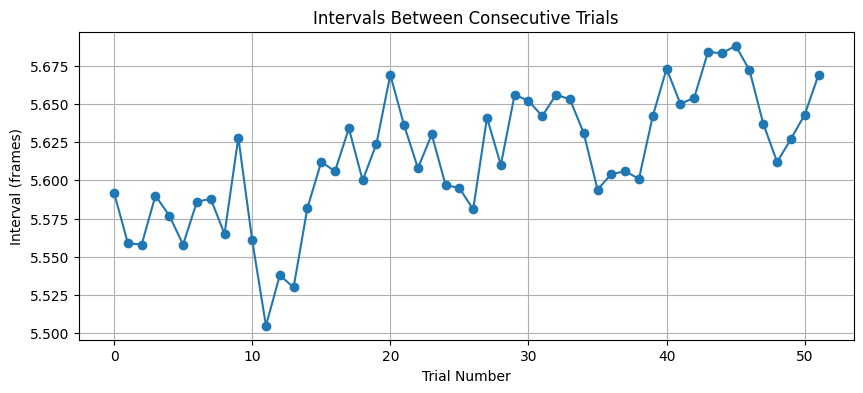

53
Generated trial_onsets_wf.npy for 20260303-154858


IndexError: list index out of range

In [54]:
preprocess_mice(config_path)

In [5]:
def load_timelite(config,session):

    ## path
    rawPath = config["paths"]["raw"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    processPath = config["paths"]["process"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(processPath, exist_ok=True)
    timePath = config["paths"]["time"].format(
        base_dir=config["base_dir"], mouse_id=config["mouse_id"], session=session
    )
    os.makedirs(timePath, exist_ok=True)
    
    items = glob(pjoin(rawPath, '202?????-??????-4*'))
    experiments = list(set([os.path.basename(item)[:15] for item in items]))
    print("Experiments found:", experiments)
    for experiment in experiments:
        ## widefield trigger_onset in second
        wfieldtrigger_path = pjoin(rawPath, experiment + ".csv")
        trial_onsets = generate_trial_onsets(wfieldtrigger_path, timePath)
        print(f"Generated trial_onsets_wf.npy for {experiment}")

        ## Bpod trial_onset in second
        matfile_path = glob(pjoin(rawPath,"*.mat"))
        mat_data = sio.loadmat(matfile_path[0], squeeze_me=True, struct_as_record=False)
        trial_timestamps = load_bpod_timestamps(mat_data, trial_onsets, timePath)
        print(f"Generated trial_timestamp.npy for {experiment}")

        ## Bpod stim onset, offset, reward time and airpuff time in second
        stim_timestamp, reward_timestamps, airpuff_timestamps = load_bpod_stim(mat_data, timePath, trial_timestamps)
        print(f"Generated stim_timestamp.npy, reward timestamps.npy, airpuff_timestamps.npy for {experiment}")

        ## Bpod lick time in second
        lick_timestamps = load_lick_time(mat_data, timePath)
        print(f"Generated lick_timestamps.npy for {experiment}")

        ## widefield frame time in second
        widetime_path_blue = pjoin(rawPath, experiment + "-470Timestamp.csv")
        widetime_path_violet = pjoin(rawPath, experiment + "-405Timestamp.csv")
        
        widefield_timestamps_blue = load_widefield_time(widetime_path_blue)
        widefield_timestamps_violet = load_widefield_time(widetime_path_violet)
        np.save(pjoin(timePath, 'widefield_timestamps_blue.npy'), widefield_timestamps_blue)
        np.save(pjoin(timePath, 'widefield_timestamps_violet.npy'), widefield_timestamps_violet)
        print(f"Generated widefield_timestamps_blue.npy, widefield_timestamps_violet.npy for {experiment}")
        print(f'Generated all time files for {experiment}')
        print('----------------------------------------')


In [6]:
def generate_trial_onsets(wfieldtrigger_path, timePath):
    
    stimfile = np.loadtxt(wfieldtrigger_path, delimiter=',')
    stim_signal = stimfile[:, 0] 
    onset_indices = (np.where(np.diff(stim_signal) == 1)[0] + 1)/1000

    start_intervals = np.diff(onset_indices)
    print(start_intervals)
    plt.figure(figsize=(10, 4))
    plt.plot(start_intervals, marker='o')
    plt.xlabel('Trial Number')
    plt.ylabel('Interval (frames)')
    plt.title('Intervals Between Consecutive Trials')
    plt.grid(True)
    plt.show()
    
    print((len(onset_indices)))
    trial_onsets = onset_indices
    np.save(pjoin(timePath, 'trial_onsets_wfield.npy'), trial_onsets)
    return trial_onsets


In [8]:
def load_widefield_time(wfieldtime_path):
    
    df = pd.read_csv(wfieldtime_path, header=None)  
    stimfile = df.to_numpy().flatten() 

    return stimfile

In [9]:
from matplotlib.pyplot import savefig

def load_bpod_timestamps(mat_data, trial_onsets, timePath) :
    session = mat_data['SessionData']
    trial_start_byBpod = session.TrialStartTimestamp
    trial_end_byBpod = session.TrialEndTimestamp
    if trial_start_byBpod.shape == trial_end_byBpod.shape:
        print("Shapes match.")
    else:
        print("Shapes do NOT match.")

    trial_interval_byBpod = trial_end_byBpod - trial_start_byBpod
    start_intervals_byBpod = np.diff(trial_start_byBpod)
    print(start_intervals_byBpod)

    start_diff = trial_start_byBpod - trial_onsets

    plt.figure(figsize=(6,4))
    plt.hist(start_diff, bins=30, color='skyblue', edgecolor='k')
    plt.xlabel('Trial Start Difference (s)')
    plt.ylabel('Count')
    plt.title('Distribution of Start Differences')
    savefig(pjoin(timePath, 'QC-Start_Difference_Histogram.png'))

    plt.figure(figsize=(8,4))
    plt.plot(start_diff, marker='o', linestyle='-')
    plt.xlabel('Trial')
    plt.ylabel('Start Difference (s)') 
    trial_end = trial_onsets + trial_interval_byBpod
    trial_timestamp = np.column_stack((trial_onsets, trial_end))  # [trial_start, trial_end]*n_trial
    np.save(pjoin(timePath, 'trial_timestamp.npy'), trial_timestamp)

    return trial_timestamp

In [10]:
def load_bpod_stim(mat_data, timePath, trial_timestamp):
    session = mat_data["SessionData"]
    n_trials = int(session.nTrials)
    ## stim onset and offset
    stim_timestamp = np.full((n_trials, 2), np.nan)  # shape: (n_trials, 2)
    for i in range(n_trials):
        try:
            trial = session.RawEvents.Trial[i].Events
            start = getattr(trial, "GlobalTimer1_Start", np.nan)
            end = getattr(trial, "GlobalTimer1_End", np.nan)
        except Exception as e:
            print(f"Trial {i+1}: missing or error ({e})")
            start, end = np.nan, np.nan

        stim_timestamp[i, 0] = start
        stim_timestamp[i, 1] = end
    
    np.save(pjoin(timePath, 'stim_timestamp.npy'), stim_timestamp)

    ## QC plot for stim duration
    stim_durations = stim_timestamp[:, 1] - stim_timestamp[:, 0]
    stim_durations = stim_durations[~np.isnan(stim_durations)]
    plt.figure(figsize=(6,4))
    plt.hist(stim_durations, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel("Stimulus Duration (s)")
    plt.ylabel("Count")
    plt.title("Distribution of Stimulus Durations")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


    pre_stim_interval = stim_timestamp[:, 0] - trial_timestamp[:, 0]
    post_stim_interval = trial_timestamp[:, 1] - stim_timestamp[:, 1]
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.hist(pre_stim_interval, bins=30)
    plt.title("Trial start → Stim start interval")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")

    plt.subplot(1, 2, 2)
    plt.hist(post_stim_interval, bins=30)
    plt.title("Stim end → Trial end interval")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

    ## reward time and airpuff time
    reward_timestamps = np.full((n_trials, 2), np.nan)
    airpuff_timestamps = np.full((n_trials, 2), np.nan)
    for i in range(n_trials):
        trial_events = session.RawEvents.Trial[i].States  

        reward = getattr(trial, "Reward", np.array([np.nan, np.nan]))
        reward = np.asarray(reward, dtype=float).flatten()
        if reward.size < 2:
            reward = np.pad(reward, (0, 2 - reward.size), constant_values=np.nan)
        reward_timestamps[i] = reward[:2]

        airpuff = getattr(trial, "AirPuff", np.array([np.nan, np.nan]))
        airpuff = np.asarray(airpuff, dtype=float).flatten()
        if airpuff.size < 2:
            airpuff = np.pad(airpuff, (0, 2 - airpuff.size), constant_values=np.nan)
        airpuff_timestamps[i] = airpuff[:2]

    np.save(os.path.join(timePath, 'reward.npy'), reward_timestamps)
    np.save(os.path.join(timePath, 'airpuff.npy'), airpuff_timestamps)
    
    ## QC plot for reward and airpuff distribution
    plt.figure(figsize=(10, 4))

    ## Reward distribution
    plt.subplot(1, 2, 1)
    plt.hist(reward_timestamps[:, 0][~np.isnan(reward_timestamps[:, 0])], bins=30, color='green', alpha=0.7, edgecolor='black')
    plt.title("Reward Start Time Distribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    # AirPuff distribution
    plt.subplot(1, 2, 2)
    plt.hist(airpuff_timestamps[:, 0][~np.isnan(airpuff_timestamps[:, 0])], bins=30, color='red', alpha=0.7, edgecolor='black')
    plt.title("AirPuff Start Time Distribution")
    plt.xlabel("Time (s)")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    savefig(pjoin(timePath, 'QC-Reward_Airpuff_Distribution.png'))


    return stim_timestamp, reward_timestamps, airpuff_timestamps

In [11]:
def load_lick_time(mat_data, timePath):
    session = mat_data["SessionData"]
    n_trials = int(session.nTrials)
    ## lick times
    lick_timestamps = []
    for i in range(n_trials):
        trial = session.RawEvents.Trial[i].Events
        licks = getattr(trial, "BNC1High", np.array([]))
        licks = np.asarray(licks, dtype=float).flatten()
        lick_timestamps.append(licks)
    np.save(pjoin(timePath, 'lick_timestamps.npy'), np.array(lick_timestamps, dtype=object))

    
    return lick_timestamps